**NOTICE:**
The U.S. Army Corps of Engineers, Risk Management Center (USACE-RMC) makes no guarantees about the results, or appropriateness of outputs, obtained from Numerics.

# 02. Model Estimation
In this notebook we will explored the different models BestFit offers to estimate parameters. Our previous notebooks have been using these methods behind the scenes to support our analyses. Parameter estimation is the process of finding the values that make a model best explain observed data. BestFit provides full uncertainty quantification through Markov Chain Monte Carlo (MCMC) sampling. It also supports Maximum Likelihood Estimation (MLE) for point estimates and the Generalized Method of Moments (GMM) for specific applications.

## What You'll Learn
- Maximum Likelihood Estimation (MLE)
- Bayesian MCMC Estimation
- Maximum A Posteriori (MAP) Estimation
- Generalized Method of Moments (GMM)
- How to validate your model with convergence checks
- How to compare models 

ADD NUMERICAL DIFF??

## Set Up

In [ ]:
import pythonnet
pythonnet.load("coreclr")

import clr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from helper_functions import resolve_bestfit_dll, resolve_numerics_dll, convert_to_dotnet_array, convert_to_dotnet_2d_array

clr.AddReference(str(resolve_numerics_dll()))
clr.AddReference(str(resolve_bestfit_dll()))

print("✓ Numerics loaded from:", resolve_numerics_dll())
print("✓ BestFit loaded from:", resolve_bestfit_dll())

from RMC.BestFit import ExactData, ExactSeries
from RMC.BestFit.Estimation import MaximumLikelihood, OptimizationMethod, BayesianAnalysis, MaximumAPosteriori, GeneralizedMethodOfMoments, MomentConditionFunction
from RMC.BestFit.Models import DataFrame, UnivariateDistribution, QuantilePrior, IGMMModel

from Numerics.Mathematics.Optimization import ParameterSet
from Numerics.Mathematics.LinearAlgebra import Vector, Matrix
from Numerics.Distributions import UnivariateDistributionType, Uniform, Normal, GeneralizedExtremeValue

from System import Double, Random, Func, Array, ValueTuple

print("✓ Imported namespaces successfully")

## Why Estimation Method Matters

Consider fitting a Generalized Extreme Value (GEV) distribution to 50 years of annual peak flows. Different estimation methods give different information:

| Method | Output | Use Case |
|--------|--------|----------|
| MLE | Point estimates, standard errors | Quick analysis, operational forecasting |
| Bayesian MCMC | Full posterior distributions | Uncertainty quantification, decision-making under uncertainty |
| GMM | Point estimates, moment conditions | Robust to distributional assumptions |
| MAP | Posterior mode | Regularized point estimate with prior information |

For life-safety applications like dam and levee risk assessment, **Bayesian MCMC is the recommended approach** because it properly propagates parameter uncertainty to design quantiles and risk estimates.

---

## Maximum Likelihood Estimation (MLE)

### Theoretical Foundation

Maximum Likelihood Estimation finds the parameter values $\hat{\theta}$ that maximize the probability of observing the data:

```math
\hat{\theta}_{\text{MLE}} = \arg\max_{\theta} \mathcal{L}(\theta | \mathbf{y}) = \arg\max_{\theta} \prod_{i=1}^{n} f(y_i | \theta)
```

Equivalently, we maximize the log-likelihood:

```math
\hat{\theta}_{\text{MLE}} = \arg\max_{\theta} \ell(\theta) = \arg\max_{\theta} \sum_{i=1}^{n} \log f(y_i | \theta)
```

### Properties of MLE

Under regularity conditions, MLE has desirable asymptotic properties:

1. Consistency: $\hat{\theta}_{\text{MLE}} \xrightarrow{p} \theta_0$ as $n \to \infty$
2. Asymptotic Normality: $\sqrt{n}(\hat{\theta}_{\text{MLE}} - \theta_0) \xrightarrow{d} N(0, I^{-1}(\theta_0))$
3. Efficiency: Achieves the Cramér-Rao lower bound asymptotically

where $I(\theta)$ is the Fisher Information matrix:

```math
I(\theta) = -E\left[\frac{\partial^2 \ell(\theta)}{\partial \theta \partial \theta^T}\right]
```

MLE Results
Log Likelihood: 314.07
 Location (ξ) : 45860.27
 Scale (α) : 8223.39
 Shape (κ) : 0.24


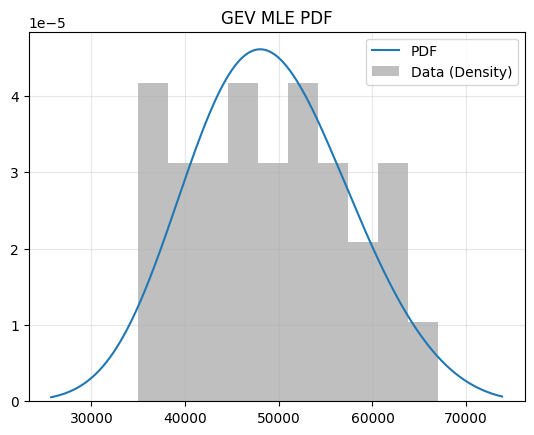

In [4]:
annual_peaks = [
    45000, 52000, 38000, 61000, 49000, 55000, 42000, 67000, 39000, 48000,
    51000, 36000, 58000, 44000, 53000, 47000, 62000, 41000, 50000, 37000,
    54000, 46000, 59000, 43000, 56000, 40000, 63000, 35000, 57000, 45000
]
peak_max=67000
peak_min=35000

df = DataFrame()
df.ExactSeries = ExactSeries(convert_to_dotnet_array(annual_peaks))

mle_model = UnivariateDistribution(df, UnivariateDistributionType.GeneralizedExtremeValue)
mle = MaximumLikelihood(mle_model)

# Choose optimization method
mle.Method = OptimizationMethod.NelderMead                 # Local optimizer (fast)
# mle.Method = OptimizationMethod.MultilevelSingleLinkage  # Global optimizer (robust)
# mle.Method = OptimizationMethod.DifferentialEvolution    # Global optimizer (very robust)

mle.Estimate()

if mle.IsEstimated:
    print("MLE Results")
    print(f"Log Likelihood: {mle.BestParameterSet.Fitness:.2f}")

    for i in range(len(mle_model.Parameters)):
        print(f" {mle_model.Parameters[i].DisplayName} : {mle.BestParameterSet.Values[i]:.2f}")

    mle_model.SetParameterValues(mle.BestParameterSet.Values)

    mle_dist = mle_model.Distribution
    mle_xmin = mle_dist.InverseCDF(0.001)
    mle_xmax = mle_dist.InverseCDF(0.999)
    mle_x = np.linspace(mle_xmin, mle_xmax, 400)
    
    mle_pdf = np.array([mle_dist.PDF(v) for v in mle_x])
    
    plt.plot(mle_x, mle_pdf, label="PDF")
    plt.hist(annual_peaks, range = (peak_min, peak_max), density=True, alpha=0.5, color='gray', label = "Data (Density)")
    plt.title(f"{mle_dist.ShortDisplayName} MLE PDF")
    plt.grid(True, alpha=0.3)
    plt.legend()
    

### Optimization Methods
BestFit provides several optimization algorithms through the Numerics library:

| Method | Type | Speed | Robustness | Recommended For |
|--------|------|-------|------------|-----------------|
| `NelderMead` | Local | Fast | Low | Well-behaved likelihoods |
| `BFGS` | Local | Fast | Medium | Smooth likelihoods |
| `Powell` | Local | Medium | Medium | Non-differentiable objectives |
| `DifferentialEvolution` | Global | Slow | High | Multimodal likelihoods |
| `MultilevelSingleLinkage` | Global | Medium | High | General use |
| `ParticleSwarm` | Global | Medium | Medium | High-dimensional problems |

**Recommendation**: Use `MultilevelSingleLinkage` for most applications. It balances computational cost with robustness to local optima.

### Handling Multiple Local Optima

Many hydrologic models have multimodal likelihoods. For example, rating curves with the power-law form $Q = \alpha(h - \xi)^\beta$ have parameter trade-offs: different combinations of $(\xi, \alpha, \beta)$ can produce similar fits.

To increase confidence in finding the global optimum we can run multiple optimizations from different starting points.

Best log likelihood across trials: 314.07
Best parameters:
 Location (ξ) : 45860.27
 Scale (α) : 8223.39
 Shape (κ) : 0.24


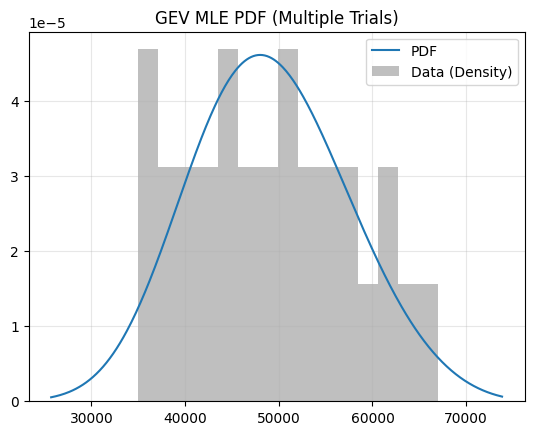

In [5]:
# Initialization
best_fitness = Double.NegativeInfinity
best_params = ParameterSet()

for trial in range(10):
    mle = MaximumLikelihood(mle_model, OptimizationMethod.NelderMead)

    # Random starting point within bounds
    random = Random(trial)
    start_values = np.zeros(mle_model.Parameters.Count)
    for i in range(mle_model.Parameters.Count):
        p = mle_model.Parameters[i]
        start_values[i] = p.LowerBound + random.NextDouble() * (p.UpperBound - p.LowerBound)
    mle.InitialValues = start_values

    mle.Estimate()

    if mle.IsEstimated and mle.BestParameterSet.Fitness > best_fitness:
        best_fitness = mle.BestParameterSet.Fitness
        best_params = mle.BestParameterSet


print(f"Best log likelihood across trials: {best_fitness:.2f}")
print("Best parameters:")
for i in range(mle_model.Parameters.Count):
    print(f" {mle_model.Parameters[i].DisplayName} : {best_params.Values[i]:.2f}")

mle_model.SetParameterValues(best_params.Values)
dist = mle_model.Distribution
xmin = dist.InverseCDF(0.001)
xmax = dist.InverseCDF(0.999)
x = np.linspace(xmin, xmax, 400)
    
pdf = np.array([dist.PDF(v) for v in x])
    
plt.plot(x, pdf, label="PDF")
plt.hist(annual_peaks, bins = 15, range = (peak_min, peak_max), density=True, alpha=0.5, color='gray', label = "Data (Density)")
plt.title(f"{dist.ShortDisplayName} MLE PDF (Multiple Trials)")
plt.grid(True, alpha=0.3)
plt.legend()
    

## Bayesian MCMC Estimation

### Theoretical Foundation

Bayesian inference treats parameters as random variables with probability distributions. We start with a prior distribution $\pi(\theta)$ encoding our beliefs before seeing data, then update to a posterior distribution after observing data $\mathbf{y}$:

```math
\pi(\theta | \mathbf{y}) = \frac{\mathcal{L}(\mathbf{y} | \theta) \cdot \pi(\theta)}{\int \mathcal{L}(\mathbf{y} | \theta) \cdot \pi(\theta) \, d\theta}
```

This is Bayes' theorem. The denominator (marginal likelihood or evidence) is typically intractable, but MCMC methods sample from the posterior without computing it.

### Why Bayesian?

Bayesian estimation offers several advantages for hydrologic applications:

1. Full Uncertainty Quantification: Get probability distributions, not just point estimates
2. Natural Framework for Prediction: Predictive distributions integrate over parameter uncertainty
3. Incorporation of Prior Information: Engineering judgment can inform priors
4. Coherent Decision-Making: Posterior distributions support risk-based decisions
5. Flexible Model Comparison: WAIC, LOO-CV, and Bayes factors

### The DEMCzs Sampler

BestFit uses the Differential Evolution Markov Chain with snooker update (DEMCzs) algorithm [[1]](#1) as its primary MCMC sampler. DEMCzs is particularly well-suited for:

- High-dimensional problems: Efficient even with 10+ parameters
- Correlated parameters: Adapts proposal scale and direction automatically
- Multimodal posteriors: Multiple chains can explore different modes

The algorithm maintains $N$ chains (typically $N = 3$) that evolve in parallel. Each chain proposes new states using differences between other chains:

```math
\theta^* = \theta^{(i)} + \gamma \cdot (\theta^{(r_1)} - \theta^{(r_2)}) + \varepsilon
```

where $r_1, r_2$ are randomly selected chains and $\gamma$ is a scaling factor.

The `BayesianAnalysis` class provides MCMC estimation.

Bayesian Analysis Results:
Parameter                  Mean     StdDev       2.5%      97.5%     Rhat      ESS
Location (ξ)          45483.415   1790.746  42551.811  48498.134    1.002  708.431
Scale (α)              8690.016   1497.275   6699.840  11323.457    1.001  611.037
Shape (κ)                 0.173      0.177     -0.122      0.439    1.000  677.729


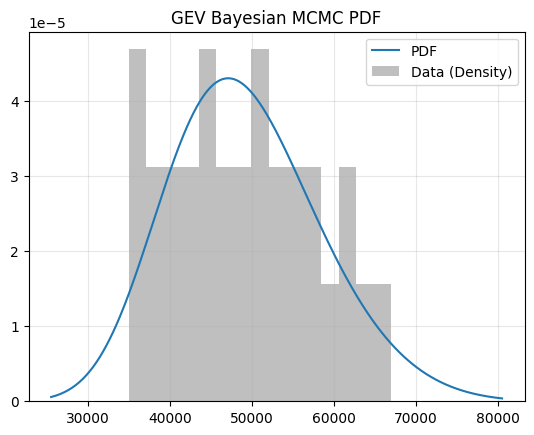

In [7]:
# Create a clean, new model
bayes_model = UnivariateDistribution(df, UnivariateDistributionType.GeneralizedExtremeValue)

# Configure Bayesian analysis
bayesian = BayesianAnalysis(bayes_model)

# Sampling parameters
bayesian.Type = BayesianAnalysis.SamplerType.DEMCzs  # Default sampler
bayesian.Iterations = 10000           # Total iterations after warmup
bayesian.WarmupIterations = 5000      # Burn-in period (discarded)
bayesian.ThinningInterval = 1         # Keep every nth sample (1 = no thinning)

# Run Bayesian estimation
bayesian.RunAsync().Wait()

results = bayesian.Results

print("Bayesian Analysis Results:")
print(F"{"Parameter":<20} {"Mean":>10} {"StdDev":>10} {"2.5%":>10} {"97.5%":>10} {"Rhat":>8} {"ESS":>8}")

params = []
for i in range(bayes_model.Parameters.Count):
    stats = results.ParameterResults[i].SummaryStatistics
    params.append(stats.Mean)

    print(
    f"{bayes_model.Parameters[i].DisplayName:<20} "
    f"{stats.Mean:10.3f} "
    f"{stats.StandardDeviation:10.3f} "
    f"{stats.LowerCI:10.3f} "
    f"{stats.UpperCI:10.3f} "
    f"{stats.Rhat:8.3f} "
    f"{stats.ESS:8.3f}"
)

bayes_model.SetParameterValues(convert_to_dotnet_array(params))
bayes_dist = bayes_model.Distribution
bayes_xmin = bayes_dist.InverseCDF(0.001)
bayes_xmax = bayes_dist.InverseCDF(0.999)
bayes_x = np.linspace(bayes_xmin, bayes_xmax, 400)
        
bayes_pdf = np.array([bayes_dist.PDF(v) for v in bayes_x])
        
plt.plot(bayes_x, bayes_pdf, label="PDF")
plt.hist(annual_peaks, bins = 15, range = (peak_min, peak_max), density=True, alpha=0.5, color='gray', label = "Data (Density)")
plt.title(f"{dist.ShortDisplayName} Bayesian MCMC PDF")
plt.grid(True, alpha=0.3)
plt.legend()

### Prior Distributions
Prior distributions encode beliefs about parameters before seeing data. These distributions are what make Bayesian analysis so special. BestFit offers several approaches.

- **Flat (Uniform) Priors:** non-informative within bounds.
- **Weakly Informative Priors:** regularize extreme values without strong assumptions.
- **Informative Priors:** incorporate engineering knowledge.
- **Jeffreys' Prior for Scale Parameters:** for scale parameters (standard deviation, etc), Jeffreys' prior is non-informative:
```math
\pi(\sigma) \propto \frac{1}{\sigma}
``` 
- **Quantile Priors:** incorporate expert judgement about specific return levels. These are particularly valuable when
    - Historical or paleoflood information suggests a range for extreme quantiles
    - Regional studies provide guidance on expected flood magnitudes
    - Engineering judgment bounds the plausible range of design value

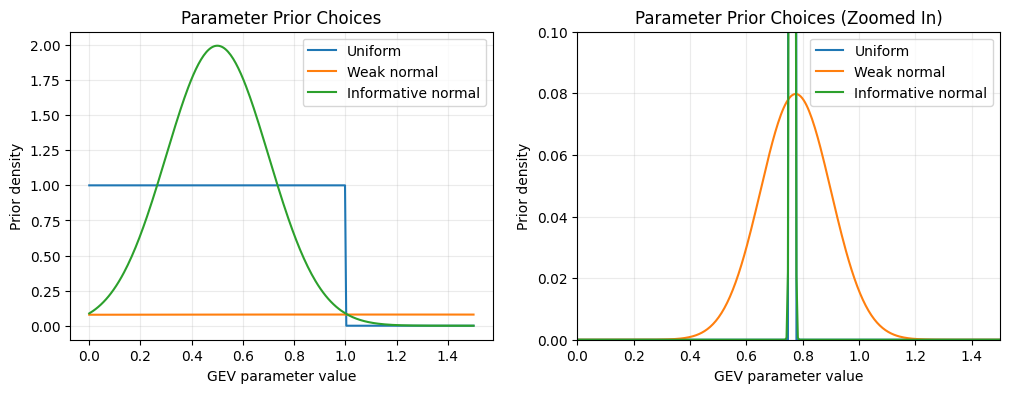

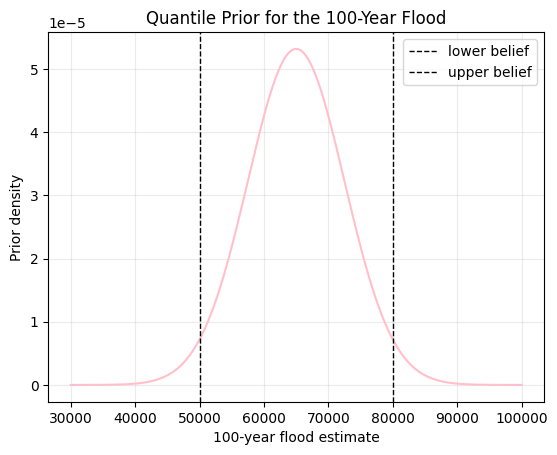

In [ ]:
model = UnivariateDistribution(df, UnivariateDistributionType.GeneralizedExtremeValue)

# Non-informative uniform prior for first parameter (shape)
lower_bound = 0
upper_bound = 1
model.Parameters[0].PriorDistribution = Uniform(lower_bound, upper_bound)

# Weakly information normal prior centered at expected value with a wide standard deviation
expected_value = 1
expected_sd = 0.5
model.Parameters[0].PriorDistribution = Normal(expected_value, 10*expected_sd)

# Informative prior based on regional analysis or expert judgment
regional_estimate = 0.5
regional_uncertainty = 0.2
model.Parameters[0].PriorDistribution = Normal(regional_estimate, regional_uncertainty)

# Jeffreys' prior
bayesian = BayesianAnalysis(model)
bayesian.UseJeffreysRuleForScale = True

# Quantile prior based on "the 100 year flood is probably between 50,000 and 80,000 cfs"
q_prior = QuantilePrior()
q_prior.ReturnPeriod = 100
q_prior.Distribution = Normal(65000, 7500)
model.QuantilePriors.Add(q_prior)

# Compare the prior distributions
prior_grid = np.linspace(0, 1.5, 300)
prior_grid_wide = np.linspace(-30,30, 300)
uniform_prior = Uniform(lower_bound, upper_bound)
weak_prior = Normal(expected_value, 10 * expected_sd)
informative_prior = Normal(regional_estimate, regional_uncertainty)
quantile_grid = np.linspace(30000, 100000, 300)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(prior_grid, [uniform_prior.PDF(float(x)) for x in prior_grid], label="Uniform")
axes[0].plot(prior_grid, [weak_prior.PDF(float(x)) for x in prior_grid], label="Weak normal")
axes[0].plot(prior_grid, [informative_prior.PDF(float(x)) for x in prior_grid], label="Informative normal")
axes[0].set_xlabel("GEV parameter value")
axes[0].set_ylabel("Prior density")
axes[0].set_title("Parameter Prior Choices")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(prior_grid, [uniform_prior.PDF(float(x)) for x in prior_grid_wide], label="Uniform")
axes[1].plot(prior_grid, [weak_prior.PDF(float(x)) for x in prior_grid_wide], label="Weak normal")
axes[1].plot(prior_grid, [informative_prior.PDF(float(x)) for x in prior_grid_wide], label="Informative normal")
axes[1].set_xlabel("GEV parameter value")
axes[1].set_ylabel("Prior density")
axes[1].set_title("Parameter Prior Choices (Zoomed In)")
axes[1].grid(alpha=0.25)
axes[1].set_xlim([0, 1.5])
axes[1].set_ylim([0, 0.1])  # focuses on the weak normal bump [code_file:0]
axes[1].legend()

fig,ax = plt.subplots()
ax.plot(quantile_grid, [q_prior.Distribution.PDF(float(q)) for q in quantile_grid], color="pink")
ax.axvline(50000, color="black", linestyle="--", linewidth=1, label="lower belief")
ax.axvline(80000, color="black", linestyle="--", linewidth=1, label="upper belief")
ax.set_xlabel("100-year flood estimate")
ax.set_ylabel("Prior density")
ax.set_title("Quantile Prior for the 100-Year Flood")
ax.grid(alpha=0.25)
ax.legend()


### MCMC Diagnostics
Successful MCMC requires verifying that chains have converged to the target distribution.

#### R-hat (Potential Scale Reduction Factor)


R-hat compares within-chain and between-chain variance [[2]](#2):

```math
\hat{R} = \sqrt{\frac{\hat{\text{Var}}(\theta | \mathbf{y})}{W}}
```

where $W$ is the within-chain variance. **Rule of thumb**: $\hat{R} < 1.1$ indicates convergence.

#### Effective Sample Size (ESS)

ESS measures the number of independent samples accounting for autocorrelation:

```math
\text{ESS} = \frac{nm}{1 + 2\sum_{k=1}^{\infty} \rho_k}
```

where $\rho_k$ is the lag-$k$ autocorrelation. **Rule of thumb**: ESS > 400 for reliable posterior summaries.

#### Visual Diagnostics

Trace plots and density plots help diagnose convergence.

Parameter               Rhat          ESS
Location (ξ)          1.0016          708
Scale (α)             1.0008          611
Shape (κ)             1.0005          678


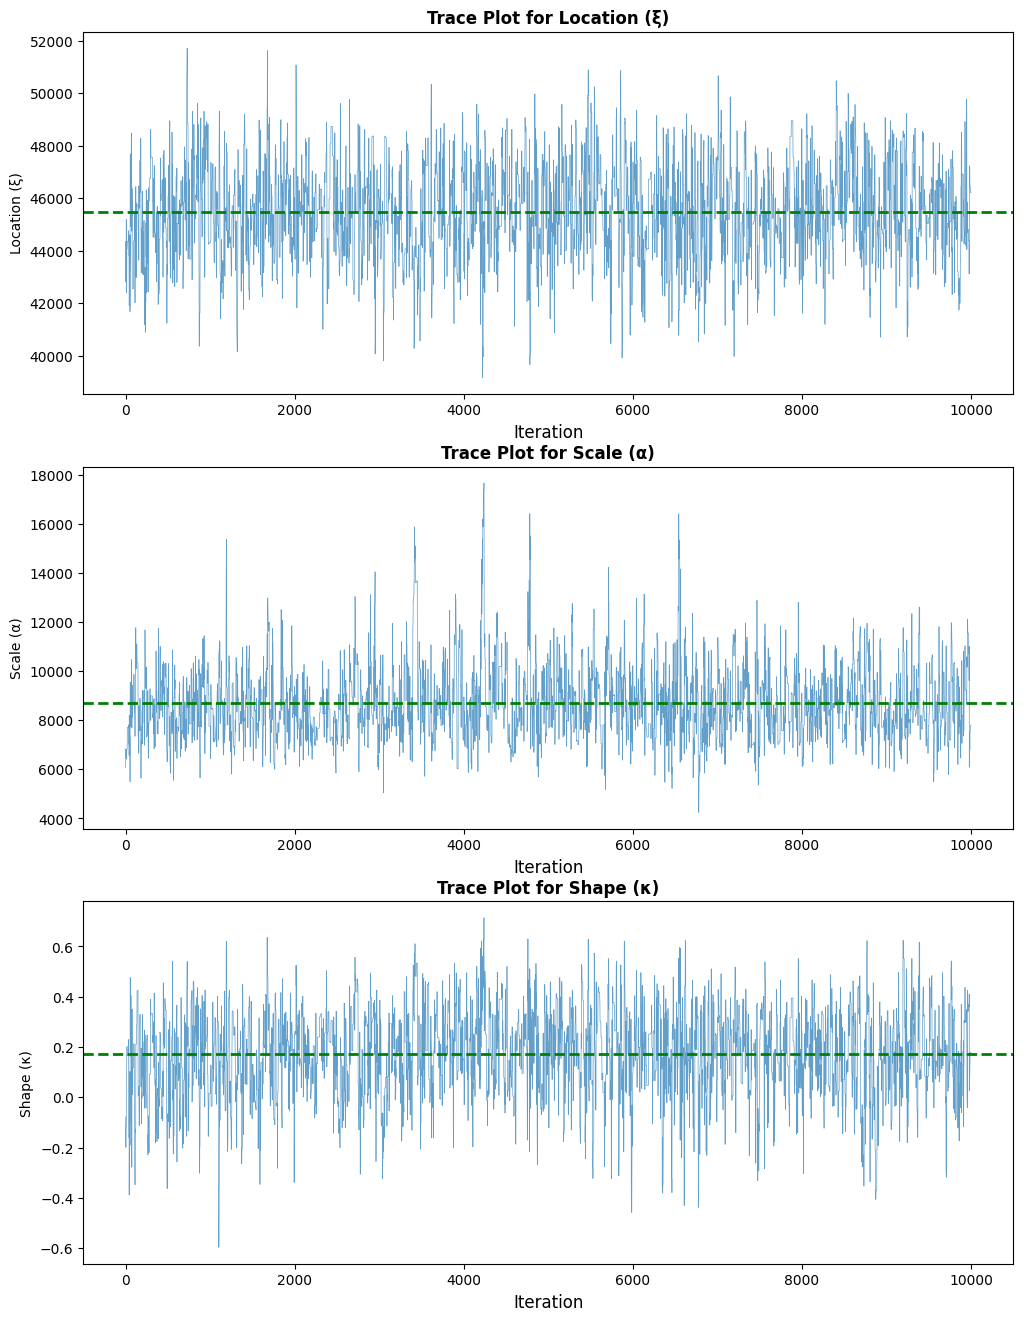

In [ ]:
print(f'{"Parameter":<15} {"Rhat":>12} {"ESS":>12}')

for i in range(bayesian.ParameterNames.Count):
    rhat = results.ParameterResults[i].SummaryStatistics.Rhat
    ess = results.ParameterResults[i].SummaryStatistics.ESS
    print(f"{bayesian.ParameterNames[i]:<15} {rhat:>12.4f} {ess:>12.0f}")

samples = results.Output
num_parameters = bayesian.ParameterNames.Count
num_samples = samples.Count

fig, axes = plt.subplots(num_parameters,1, figsize=(12,16))

for i in range(num_parameters):
    parameter_samples = np.zeros(num_samples)
    for j in range(num_samples):
        parameter_samples[j] = samples[j].Values[i]
    axes[i].plot(parameter_samples, linewidth=0.5, alpha=0.7)
    axes[i].axhline(np.mean(parameter_samples), color='green', linestyle='--', linewidth=2, label=f'Posterior Mean = {np.mean(parameter_samples):.2f}')
    axes[i].set_xlabel('Iteration', fontsize=12)
    axes[i].set_ylabel(f'{bayesian.ParameterNames[i]}')
    axes[i].set_title(f'Trace Plot for {bayesian.ParameterNames[i]}', fontsize=12, fontweight='bold')

Everything seems to be looking good! The model has correctly converged to a posterior space and is giving us plausible values.

## Maximum A Posteriori (MAP) Estimation
MAP estimation find the mode of the posterior distribution:

```math
\hat{\theta}_{\text{MAP}} = \arg\max_{\theta} \pi(\theta | \mathbf{y}) = \arg\max_{\theta} \left[ \ell(\theta) + \log \pi(\theta) \right]
```

MAP is a regularized version of MLE - the prior acts as a penalty on extreme parameter values.

When to use MAP:
- Quick point estimate with prior regularization
- Starting point for MCMC
- When full posterior isn't needed

MAP Estimates
Location (ξ) : 45792.7469
Scale (α) : 8015.7620
Shape (κ) : 0.2185


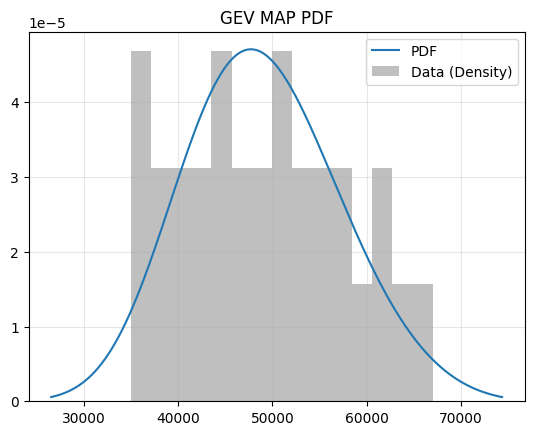

In [8]:
map_model = UnivariateDistribution(df, UnivariateDistributionType.GeneralizedExtremeValue)

map = MaximumAPosteriori(map_model)
map.Estimate()

if map.IsEstimated:
    print("MAP Estimates")
    for i in range(map_model.Parameters.Count):
        print(f'{map_model.Parameters[i].DisplayName} : {map.BestParameterSet.Values[i]:.4f}')

map_model.SetParameterValues(map.BestParameterSet.Values)
map_dist = map_model.Distribution
map_xmin = map_dist.InverseCDF(0.001)
map_xmax = map_dist.InverseCDF(0.999)
map_x = np.linspace(map_xmin, map_xmax, 400)

map_pdf = np.array([map_dist.PDF(v) for v in map_x])

plt.plot(map_x, map_pdf, label="PDF")
plt.hist(annual_peaks, bins=15, range = (peak_min, peak_max), density = True, alpha=0.5, color='gray', label = "Data (Density)")
plt.title(f"{dist.ShortDisplayName} MAP PDF")
plt.grid(True, alpha=0.3)
plt.legend()

## Generalized Method of Moments (GMM)
GMM estimates parameters by matching sample moments to theoretical moments:

```math
\hat{\theta}_{\text{GMM}} = \arg\min_{\theta} g(\theta)^T W g(\theta)
```

where $g(\theta)$ is a vector of moment conditions and $W$ is a weighting matrix.

Advantages of GMM:
- Robust to distributional misspecification
- Only requires moment assumptions, not full likelihood
- Efficient two-step estimator available

**Note**: RMC-BestFit uses GMM only for specific applications. MLE or Bayesian MCMC are preferred for most analyses.


GMM Estimates
Location             49767.6672
Scale                13943.1349
Shape                    0.3200


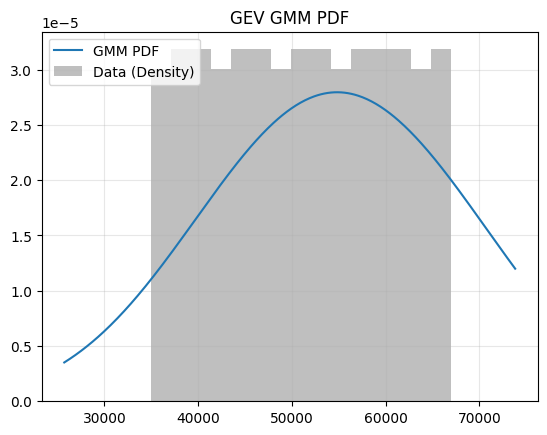

In [9]:
df = DataFrame()
df.ExactSeries = ExactSeries(convert_to_dotnet_array(annual_peaks))
x = np.array(x)

# Raw moments can be very large for flow data because x^3 is huge. Scaling the moment equations keeps the optimizer from seeing an ill-conditioned objective.
x_scale = max(float(np.std(x, ddof=1)), 1e-6)

def moment_conditions(theta):
    loc, scale, shape = [float(v) for v in theta]

    # Use Numerics to compute GEV moments
    gev = GeneralizedExtremeValue(loc, scale, shape)
    mean, stdev, skew, kurt = [float(v) for v in gev.MomentsFromParameters(convert_to_dotnet_array(theta))]

    # The pointwise conditions below are raw moment condition so convert Numerics output to raw moments E[X], E[X^2], E[X^3]
    variance = stdev**2
    model_moments = np.array([ mean, variance + mean**2, skew * stdev**3 + 3.0 * mean * variance + mean**3, ])

    # gi is the n-by-3 matrix of per-observation moment errors:
    #   column 1: x_i      - E[X]
    #   column 2: x_i^2    - E[X^2]
    #   column 3: x_i^3    - E[X^3]
    # Dividing columns by x_scale, x_scale^2, and x_scale^3 does not change the zero of the moment equations, but it greatly improves numerical scaling
    powers = np.array([x_scale, x_scale**2, x_scale**3])
    gi = (np.column_stack([x, x**2, x**3]) - model_moments) / powers
    
    # g is the sample average moment error that GMM tries to drive to zero.
    g = gi.mean(axis=0)

    # s is the covariance of the pointwise moment errors and becomes the GMM weighting matrix input. The tiny ridge avoids singular covariance matrices.
    s = np.cov(gi, rowvar=False, bias=True) + np.eye(3) * 1e-4

    s_net = Array.CreateInstance(Double, 3, 3)

    for i in range(3):
        for j in range(3):
            s_net[i, j] = float(s[i, j])

    # Have to return Numerics .NET Vector and Matrix objects.
    g_net = Vector(Array[Double](g.tolist()))
    s_net = Matrix(s_net)

    return ValueTuple[Vector, Matrix](g_net, s_net)

gmm = GeneralizedMethodOfMoments( MomentConditionFunction(moment_conditions),
                                    3,          # parameters: location, scale, shape
                                    3,          # moments: E[X], E[X^2], E[X^3]
                                    len(annual_peaks),
                                    Array[Double]([float(x.mean()), x_scale, 0.0]),
                                    Array[Double]([-1e10, 1e-6, -0.5]),
                                    Array[Double]([1e10, 1e10, 0.32]), )

gmm.Estimate()

if gmm.IsEstimated:
    print("GMM Estimates")
    for name, value in zip(["Location", "Scale", "Shape"], gmm.BestParameterSet.Values):
        print(f"{name:<20} {float(value):10.4f}")

loc, scale, shape = [float(v) for v in gmm.BestParameterSet.Values]
gmm_dist = GeneralizedExtremeValue(loc, scale, shape)

gmm_xmin = dist.InverseCDF(0.001)
gmm_xmax = dist.InverseCDF(0.999)
gmm_grid = np.linspace(gmm_xmin, gmm_xmax, 400)
gmm_pdf = np.array([gmm_dist.PDF(float(v)) for v in gmm_grid])

plt.plot(gmm_grid, gmm_pdf, label="GMM PDF")
plt.hist(x, bins=15, range = (peak_min, peak_max), density=True, alpha=0.5, color="gray", label="Data (Density)")
plt.title(f"{dist.ShortDisplayName} GMM PDF")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Model Comparison

After fitting multiple models, we need criteria to select among them.

### Akaike Information Criterion (AIC)

```math
\text{AIC} = -2\ell(\hat{\theta}) + 2k
```

where $k$ is the number of parameters. Lower AIC is better.

### Bayesian Information Criterion (BIC)

```math
\text{BIC} = -2\ell(\hat{\theta}) + k \log(n)
```

BIC penalizes complexity more heavily than AIC for $n > 7$.


### Deviance Information Criterion (DIC)

DIC is a Bayesian alternative to AIC:

```math
\text{DIC} = \bar{D} + p_D
```

where $\bar{D}$ is the posterior mean deviance and $p_D$ is the effective number of parameters.

### WAIC and LOO-CV

For fully Bayesian model comparison, ***RMC-BestFit*** supports:

- **WAIC** (Widely Applicable Information Criterion): Uses pointwise predictive densities
- **LOO-CV** (Leave-One-Out Cross-Validation) with PSIS (Pareto-Smoothed Importance Sampling)

These are computed from MCMC output using the `PointwiseDataLogLikelihood` method.


MLE AIC: 634.133
MLE BIC: 638.336

Bayesian MCMC DIC: 633.865
Bayesian MCMC WAIC: 633.633
Bayesian MCMC LOO-Information Criterion: 632.206

MAP AIC: 710.171
MAP BIC: 714.375

Model           Location (ξ)   Scale (α)   Shape (κ)
MLE               45860.269    8223.386       0.237
Bayesian MCMC     45483.415    8690.016       0.173
MAP               45792.747    8015.762       0.218
GMM               49767.667   13943.135       0.320


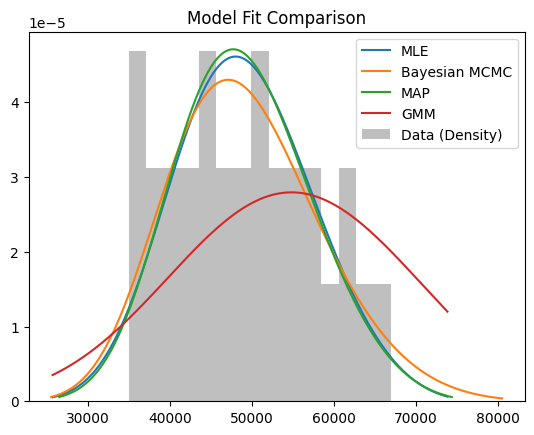

In [12]:
print(f'MLE AIC: {mle.GetAIC():.3f}')
print(f'MLE BIC: {mle.GetBIC(len(annual_peaks)):.3f}')

# We must run the sampler again here (otherwise we will just get nan values)
# Each time we run this cell, the DIC, WAIC, and LOOIC values will be a little different due to the randomness of MCMC sampling
# !!! COME BACK: IS THERE A WAY TO SET A SEED??? HERE OR ABOVE !!!
bayesian.RunAsync().Wait()
print(f'\nBayesian MCMC DIC: {bayesian.DIC:.3f}')
print(f'Bayesian MCMC WAIC: {bayesian.WAIC:.3f}')
print(f'Bayesian MCMC LOO-Information Criterion: {bayesian.LOOIC:.3f}')

print(f'\nMAP AIC: {map.GetAIC():.3f}')
print(f'MAP BIC: {map.GetBIC(len(annual_peaks)):.3f}')

print(f'\n{"Model":<15} {"Location (ξ)":>11} {"Scale (α)":>11} {"Shape (κ)":>11}')
print(f'{"MLE":<15} {mle.BestParameterSet.Values[0]:>11.3f} {mle.BestParameterSet.Values[1]:>11.3f} {mle.BestParameterSet.Values[2]:>11.3f}')
print(f'{"Bayesian MCMC":<15} {results.ParameterResults[0].SummaryStatistics.Mean:>11.3f} {results.ParameterResults[1].SummaryStatistics.Mean:>11.3f} {results.ParameterResults[2].SummaryStatistics.Mean:>11.3f}')
print(f'{"MAP":<15} {map.BestParameterSet.Values[0]:11.3f} {map.BestParameterSet.Values[1]:11.3f} {map.BestParameterSet.Values[2]:11.3f}')
print(f'{"GMM":<15} {gmm.BestParameterSet.Values[0]:11.3f} {gmm.BestParameterSet.Values[1]:11.3f} {gmm.BestParameterSet.Values[2]:11.3f}')

# GRAPH?
plt.plot(mle_x, mle_pdf, label="MLE")
plt.plot(bayes_x, bayes_pdf, label = "Bayesian MCMC")
plt.plot(map_x, map_pdf, label = "MAP")
plt.plot(gmm_grid, gmm_pdf, label="GMM")
plt.hist(annual_peaks, bins=15, range = (peak_min, peak_max), density = True, alpha=0.5, color='gray', label = "Data (Density)")
plt.title("Model Fit Comparison")
plt.legend()

## Practical Recommendations

### Choosing an Estimation Method

| Situation | Recommended Method |
|-----------|-------------------|
| Quick exploratory analysis | MLE |
| Uncertainty in design values matters | Bayesian MCMC |
| Prior information available | Bayesian MCMC |
| Very large dataset (n > 10,000) | MLE, then Bayesian if needed |
| Model selection among many candidates | MLE with AIC/BIC, then Bayesian for finalist |
| Life-safety decision | Bayesian MCMC (mandatory) |

### MCMC Settings

| Parameter | Typical Value | Guidance |
|-----------|---------------|----------|
| `Iterations` | 10,000-50,000 | More for complex models |
| `WarmupIterations` | 50% of Iterations | Allow chains to find high-probability region |
| `ThinningInterval` | 1-10 | Increase if storage is limited |
| Chains | 3+ | Minimum 3 for R-hat computation |

### Troubleshooting Convergence

| Problem | Symptom | Solution |
|---------|---------|----------|
| Slow mixing | High autocorrelation, low ESS | More iterations, reparameterize |
| Non-convergence | R-hat > 1.1 | Longer warmup, better initialization |
| Multimodality | Chains stuck in different regions | Use DEMCzs, more chains |
| Numerical issues | NaN in likelihood | Check parameter bounds, transforms |

## Summary
In this notebook you:       
$\checkmark$ Explored 4 methods of model estimation     
$\checkmark$ Initialized each method differently     
$\checkmark$ Ran the estimation methods     
$\checkmark$ Used convergence and accuracy diagnostics

## Exercises
1. Generate normally distributed data (with Numerics GenerateRandomValues() method or Python)
2. Fit an MLE model to this data and estimate the parameters
3. Fit a Bayesian MCMC model to this data with a Normal prior on $\mu$ and an Exponential prior on $\sigma$
4. Compare the two models and their output

## References

<a id="1">[1]</a>
ter Braak, C.J.F. and Vrugt, J.A. (2008). "Differential Evolution Markov Chain with snooker updater and fewer chains." *Statistics and Computing*, 18(4), 435-446.

<a id="2">[2]</a>
Gelman, A. and Rubin, D.B. (1992). "Inference from iterative simulation using multiple sequences." *Statistical Science*, 7(4), 457-472.